In [243]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [244]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive')


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

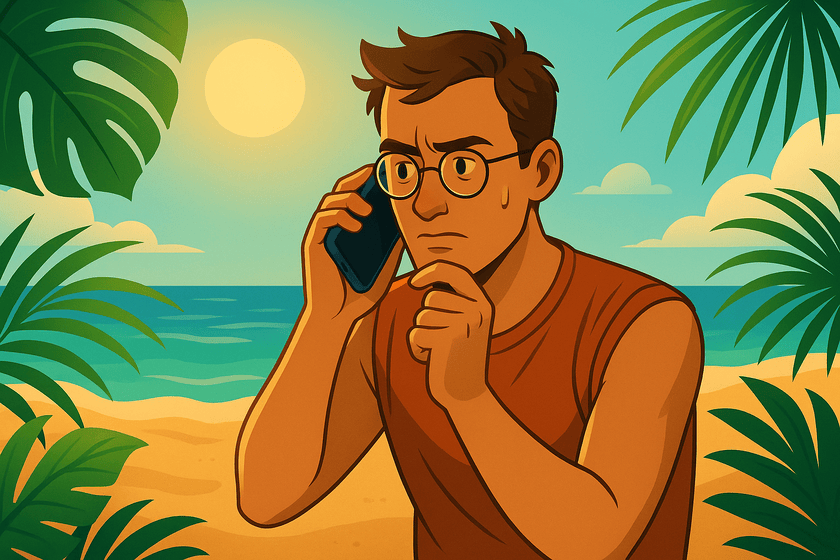

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [245]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [246]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Usuwanie lub zastępowanie wartości brakujących**

In [247]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


In [248]:
missing_vals = titanic_df.isna().sum()
missing_vals_perc = np.round(missing_vals / len(titanic_df) * 100, 2)
print(missing_vals_perc[missing_vals_perc > 0])

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


Najwięcej wartości brakujących występuje dla zmiennej Cabin. Zmnienna ta ponadto jest identyfikatorem kabiny nieprzydatnym w analizie, a więc można ją usunąć. Braki w Age i Fare zastępujemy medianą, a w Embarked dominantą (jest ich bardzo mało).

In [249]:
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"]) # zmienne Name oraz Ticket, stanowiące odpowiednio
                                                                  #imię oraz identyfikator biletu także można usunąć
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

In [250]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Skutecznie usunąliśmy lub zastąpiliśmy wartości brakujące.

# **Tworzenie przydatnych zmiennych**

Dodaję kolumnę isChild (czy pasażer jest dzieckiem) oraz FamilySize (liczbę rodziny).

In [251]:
titanic_df["isChild"] = titanic_df["Age"] < 18
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df['Parch'] + 1

# **Dostosowanie typów zmiennych**

In [252]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object
isChild,bool
FamilySize,int64


Płeć, port w którym pasażer wsiadł oraz klasa biletu powinny być zmiennymi jakościowymi (inaczej kategorycznymi). Zamieniamy odpowienne zmienne.

In [253]:
titanic_df["Embarked"] = titanic_df["Embarked"].astype("category")
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
titanic_df["isChild"] = titanic_df["isChild"].astype("category")
titanic_df["Pclass"] = pd.Categorical(titanic_df["Pclass"], categories=[1, 2, 3], ordered=True) # dodatkowo, dla zmiennej Pclass dodaję hieratchię wartości,
                                                                                                # pierwsza klasa jest najdroższa, trzecia najtańsza

# **Badanie występowania wartości odstających**

Najłatwiej to zwizualizować przy pomocy wykresów pudełkowych.

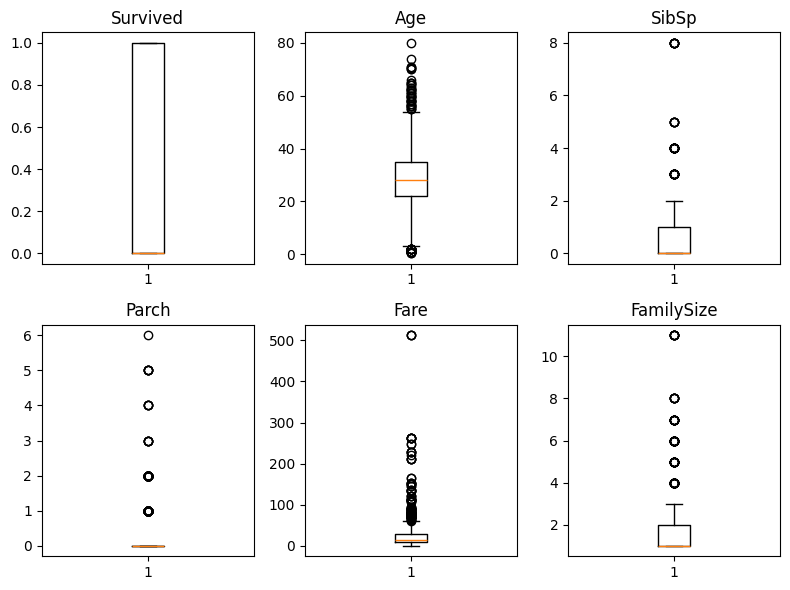

In [254]:
import matplotlib.pyplot as plt

numeric_cols = titanic_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(8, 6))

for idx, column in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, idx)
    plt.boxplot(titanic_df[column])
    plt.title(f'{column}')

plt.tight_layout()
plt.show()

Jak widać występują wartości odstające, nie są one jednak czymś szokującym, wiek może być różny tak samo jak liczba członków rodziny. Zakresy zmiennych zdają się być normalne.

# **Wizualizacja zmiennych**

Teraz podejmę się zwizualizowania zmiennych, zwłaszcza w korelacji z zmienną Survived, gdyż ta informacja jest dla nas najważniejsza.

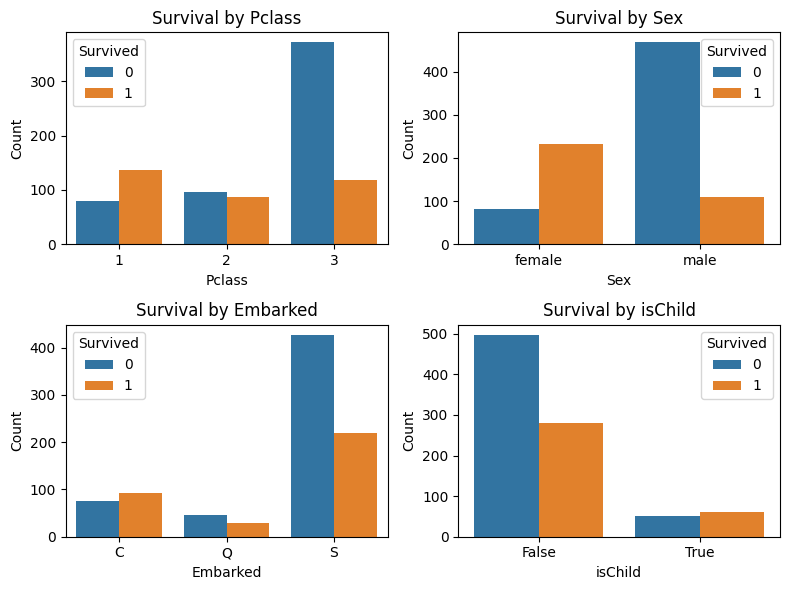

In [255]:
import seaborn as sns

categorical_cols = titanic_df.select_dtypes(include=['category']).columns

plt.figure(figsize=(8, 6))

for idx, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, idx)
    sns.countplot(data=titanic_df, x=column, hue='Survived')
    plt.title(f'Survival by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

Jak widać, klasa biletu, płeć, oraz wiek miały wpływ na przeżycie. Największy odsetek przeżywalności występował wśród osób w pierwszej klasie oraz wsród kobiet. Wśród dzieci odsetek przeżywalności także był nieco większy niż wśród dorosłych.

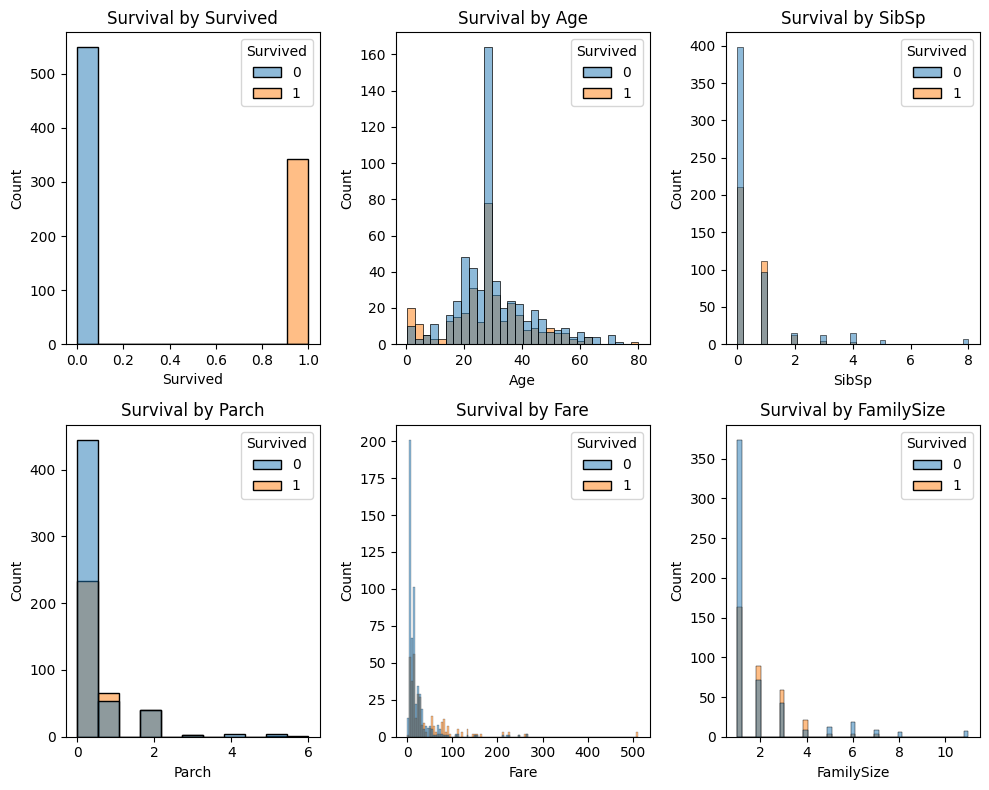

In [256]:
plt.figure(figsize=(10, 8))

for idx, column in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, idx)
    sns.histplot(data=titanic_df, x=column, hue='Survived')
    plt.title(f'Survival by {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

Można zauważyć, że osoby młodsze (dzieci) przeżywały częściej. Dotkowo widać, że posiadacze najtańszych biletów umierali najczęściej.

Zmienne SibSp, Parch, Fare oraz FamilySize mają rozkład wyraźnie prawostronnie skośny. Tylko zmienna Age przypomina rozkład normalny.

# **Kodowanie cech**

Kodowanie cech jest istotne z perspektywy prostej reprezentacji danych, co jest ważne przy uczeniu maszynowym.

In [257]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['isChild'] = titanic_df['isChild'].astype(int)

titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int) #one-hot encoding dla zmiennej Embarked
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,isChild,FamilySize,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,2,0,1
2,1,1,1,38.0,1,0,71.2833,0,2,0,0
3,1,3,1,26.0,0,0,7.9250,0,1,0,1
4,1,1,1,35.0,1,0,53.1000,0,2,0,1
5,0,3,0,35.0,0,0,8.0500,0,1,0,1
